In [157]:
# Importing the libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Business Understanding

## Problem Statement

Walmart operates multiple stores and departments where weekly sales vary due to factors such as holidays, promotional markdowns, store characteristics, weather conditions, and economic indicators. Accurately forecasting future demand is essential to ensure the right products are available at the right time while minimizing inventory costs.

## Business Objective

The objective of this project is to build a demand forecasting model that predicts **Weekly Sales** for each **Store** and **Department** using historical sales data and business-related factors such as **Temperature**, **Fuel Price**, **MarkDowns**, **CPI**, **Unemployment**, and **Holiday** information.

Accurate demand forecasts will help Walmart:
- Optimize inventory planning.
- Reduce stock shortages and excess inventory.
- Improve supply chain and staffing decisions.
- Plan promotions more effectively.
- Increase operational efficiency and business revenue.

## Project Goal

Develop, evaluate, and compare multiple forecasting models to identify the best-performing model for predicting weekly sales and provide business insights into the factors that influence demand.

## 1. Data Loading

In [158]:
from pathlib import Path

# data paths
train_path = Path("data/raw/train.csv")
test_path = Path("data/raw/test.csv")
features_path = Path("data/raw/features.csv")
stores_path = Path("data/raw/stores.csv")


# loading using pandas
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
features_df = pd.read_csv(features_path)
stores_df = pd.read_csv(stores_path)

# checking
print(train_df.head(3))
print("---------------")
print(test_df.head(3))
print("---------------")
print(features_df.head(3))
print("---------------")
print(stores_df.head(3))
print("---------------")

   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
---------------
   Store  Dept        Date  IsHoliday
0      1     1  2012-11-02      False
1      1     1  2012-11-09      False
2      1     1  2012-11-16      False
---------------
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31        2.57        NaN        NaN   
1      1  2010-02-12        38.51        2.55        NaN        NaN   
2      1  2010-02-19        39.93        2.51        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5    CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN 211.10          8.11      False  
1        NaN        NaN        NaN 211.24          8.11       True  
2        NaN        NaN        NaN 211.29          8.11      False  
---------------
   Store Type    Size
0      1 

In [160]:
# cheching the wheather train, test, features data are of the same size for merging
print("Train_df frist rows",train_df.head(3))
print("---------------")
print("Features df first_rows",features_df.head(3))
print("---------------")
print("test df Last_rows",test_df.tail(3))
print("---------------")
print("Features df last_rows",features_df.tail(3))
print("---------------")

Train_df frist rows    Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
---------------
Features df first_rows    Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31        2.57        NaN        NaN   
1      1  2010-02-12        38.51        2.55        NaN        NaN   
2      1  2010-02-19        39.93        2.51        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5    CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN 211.10          8.11      False  
1        NaN        NaN        NaN 211.24          8.11       True  
2        NaN        NaN        NaN 211.29          8.11      False  
---------------
test df Last_rows         Store  Dept        Date  IsHoliday
115061     45    98  2013-07-12      False
115062     45    98  2013-07-19      False
115063   

In [161]:
print(train_df.info())
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115064 entries, 0 to 115063
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Store      115064 non-null  int64 
 1   Dept       115064 non-null  int64 
 2   Date       115064 non-null  object
 3   IsHoliday  115064 non-null  bool  
dtypes: bool(1), int64(2), object(1)
memory usage: 2.7+ MB
None


In [162]:
print(len(features_df))
print(len(train_df))
print(len(test_df))

8190
421570
115064


In [163]:
# Merging the datasets
train_df = train_df.merge(features_df, on=["Store", "Date"], how="left")
train_df = train_df.merge(stores_df, on="Store", how="left")

test_df = test_df.merge(features_df, on=["Store", "Date"], how="left")
test_df = test_df.merge(stores_df, on="Store", how="left")

In [164]:
print(train_df.shape)
print(test_df.shape)

(421570, 17)
(115064, 16)


In [165]:
train_df.sample(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
181187,19,31,2010-05-28,2384.34,False,68.85,3.05,NaN,NaN,NaN,NaN,NaN,132.29,8.19,False,A,203819
205806,21,85,2010-12-03,1940.09,False,50.43,2.71,NaN,NaN,NaN,NaN,NaN,211.27,8.16,False,B,140167
413740,45,13,2011-11-04,25466.52,False,43.92,3.55,NaN,NaN,NaN,NaN,NaN,187.97,8.52,False,B,118221
343133,36,38,2010-11-05,20867.04,False,62.72,2.65,NaN,NaN,NaN,NaN,NaN,210.72,8.48,False,A,39910
12101,2,13,2012-10-19,45272.78,False,68.08,3.59,4461.89,NaN,1.14,1579.67,2642.29,223.06,6.17,False,A,202307


In [166]:
# droping the is_holiday which is twice in the datasets

train_df.drop(columns=['IsHoliday_y'], inplace=True)
test_df.drop(columns=['IsHoliday_y'], inplace=True)

In [167]:
train_df.sample(5)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
178802,19,12,2010-11-26,4310.61,True,42.62,3.19,NaN,NaN,NaN,NaN,NaN,132.84,8.07,A,203819
262192,27,41,2010-04-02,3214.00,False,46.90,2.96,NaN,NaN,NaN,NaN,NaN,135.75,8.06,A,204184
60341,7,10,2011-02-18,21992.86,False,17.30,3.05,NaN,NaN,NaN,NaN,NaN,191.92,8.82,B,70713
57294,6,83,2011-01-21,4349.00,False,46.20,3.02,NaN,NaN,NaN,NaN,NaN,213.34,6.86,A,202505
179368,19,17,2010-10-15,16972.06,False,51.32,3.00,NaN,NaN,NaN,NaN,NaN,132.76,8.07,A,203819


In [169]:
# Create the folder if it doesn't exist
output_path = Path("data/merged_data")
output_path.mkdir(parents=True, exist_ok=True)

# Save the merged datasets
train_df.to_csv(output_path / "train_merged.csv", index=False)
test_df.to_csv(output_path / "test_merged.csv", index=False)

print("Merged datasets saved successfully!")
print(f"Train: {output_path / 'train_merged.csv'}")
print(f"Test : {output_path / 'test_merged.csv'}")

Merged datasets saved successfully!
Train: data\merged_data\train_merged.csv
Test : data\merged_data\test_merged.csv


## 2. Data Assessing

In [28]:
# Set the global float formatting to 2 decimal places
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [34]:
train_df.shape

(421570, 16)

In [29]:
train_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.57,NaN,NaN,NaN,NaN,NaN,211.10,8.11,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.55,NaN,NaN,NaN,NaN,NaN,211.24,8.11,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.51,NaN,NaN,NaN,NaN,NaN,211.29,8.11,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.56,NaN,NaN,NaN,NaN,NaN,211.32,8.11,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.62,NaN,NaN,NaN,NaN,NaN,211.35,8.11,A,151315


In [30]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday_x   421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [31]:
train_df.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.00,421570.00,421570.00,421570.00,421570.00,150681.00,111248.00,137091.00,134967.00,151432.00,421570.00,421570.00,421570.00
mean,22.20,44.26,15981.26,60.09,3.36,7246.42,3334.63,1439.42,3383.17,4628.98,171.20,7.96,136727.92
std,12.79,30.49,22711.18,18.45,0.46,8291.22,9475.36,9623.08,6292.38,5962.89,39.16,1.86,60980.58
min,1.00,1.00,-4988.94,-2.06,2.47,0.27,-265.76,-29.10,0.22,135.16,126.06,3.88,34875.00
25%,11.00,18.00,2079.65,46.68,2.93,2240.27,41.60,5.08,504.22,1878.44,132.02,6.89,93638.00
50%,22.00,37.00,7612.03,62.09,3.45,5347.45,192.00,24.60,1481.31,3359.45,182.32,7.87,140167.00
75%,33.00,74.00,20205.85,74.28,3.74,9210.90,1926.94,103.99,3595.04,5563.80,212.42,8.57,202505.00
max,45.00,99.00,693099.36,100.14,4.47,88646.76,104519.54,141630.61,67474.85,108519.28,227.23,14.31,219622.00


In [35]:
train_df.describe(include="object").T

,count,unique,top,freq
Date,421570,143,2011-12-23,3027
Type,421570,3,A,215478


In [32]:
# checking for null values
train_df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [33]:
# checking for duplicate rows
train_df.duplicated().sum()


np.int64(0)

In [37]:
# unique values
train_df.nunique()

Store               45
Dept                81
Date               143
Weekly_Sales    359464
IsHoliday_x          2
Temperature       3528
Fuel_Price         892
MarkDown1         2277
MarkDown2         1499
MarkDown3         1662
MarkDown4         1944
MarkDown5         2293
CPI               2145
Unemployment       349
Type                 3
Size                40
dtype: int64

## Data Assessment Summary

Based on the initial assessment, the following observations were made:

- The dataset contains **421,570 records** and **16 features**, representing weekly sales information across multiple Walmart stores and departments.
- The dataset contains a mix of **numerical, categorical, boolean, and datetime-related** variables. The `Date` column is currently stored as an object and requires conversion to datetime format.
- No duplicate records were found in the dataset.
- The promotional variables (`MarkDown1` to `MarkDown5`) contain a significant number of missing values and will require appropriate treatment during data cleaning.
- The target variable (`Weekly_Sales`) contains a few negative values, which may represent product returns or accounting adjustments and should be investigated further.
- The dataset includes economic indicators such as **CPI**, **Fuel Price**, and **Unemployment**, along with weather information (**Temperature**) and store characteristics (**Type** and **Size**), which can provide valuable predictive information for forecasting weekly sales.
- The dataset spans **143 unique weekly dates**, making it suitable for time series analysis and forecasting.
- The categorical feature `Type` contains **three store categories (A, B, and C)**, while `IsHoliday_x` indicates whether a given week includes a holiday.

Overall, the dataset is well-structured with no duplicate records. The primary data quality issue is the substantial amount of missing data in the markdown-related features, which will be addressed during the data cleaning stage.

## 3. Data Cleaning

In [50]:
# saving a copy
df = train_df.copy()

In [51]:
# Converting dtype for the Date col

df["Date"] = pd.to_datetime(df["Date"])

In [55]:
# checking
df['Date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 421570 entries, 0 to 421569
Series name: Date
Non-Null Count   Dtype         
--------------   -----         
421570 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.2 MB


In [56]:
# changing col name for Holiday

df.rename(columns={'IsHoliday_x':'IsHoliday'}, inplace=True)

In [57]:
# Replace missing values in the MarkDown columns with 0, as NaN indicates no promotional markdown was applied.

markdown_cols = [
    "MarkDown1","MarkDown2","MarkDown3",
    "MarkDown4","MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

In [63]:
# checking missing values again
df.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [59]:
# droping if duplicates 
df.drop_duplicates(inplace=True)


print(df.duplicated().sum())

0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [64]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.00,421570.00,421570,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00
mean,22.20,44.26,2011-06-18 08:30:31.963375104,15981.26,60.09,3.36,2590.07,879.97,468.09,1083.13,1662.77,171.20,7.96,136727.92
min,1.00,1.00,2010-02-05 00:00:00,-4988.94,-2.06,2.47,0.00,-265.76,-29.10,0.00,0.00,126.06,3.88,34875.00
25%,11.00,18.00,2010-10-08 00:00:00,2079.65,46.68,2.93,0.00,0.00,0.00,0.00,0.00,132.02,6.89,93638.00
50%,22.00,37.00,2011-06-17 00:00:00,7612.03,62.09,3.45,0.00,0.00,0.00,0.00,0.00,182.32,7.87,140167.00
75%,33.00,74.00,2012-02-24 00:00:00,20205.85,74.28,3.74,2809.05,2.20,4.54,425.29,2168.04,212.42,8.57,202505.00
max,45.00,99.00,2012-10-26 00:00:00,693099.36,100.14,4.47,88646.76,104519.54,141630.61,67474.85,108519.28,227.23,14.31,219622.00
std,12.79,30.49,NaN,22711.18,18.45,0.46,6052.39,5084.54,5528.87,3894.53,4207.63,39.16,1.86,60980.58


In [75]:
# Negative Weekly Sales (checking how many weekly sales are Negative)

print("No of Negative Weekly Sales Values :",(df["Weekly_Sales"] < 0).sum())


df[df["Weekly_Sales"] < 0][["Store", "Dept", "Date", "Weekly_Sales"]]


No of Negative Weekly Sales Values : 1285


,Store,Dept,Date,Weekly_Sales
846,1,6,2012-08-10,-139.65
2384,1,18,2012-05-04,-1.27
6048,1,47,2010-02-19,-863.00
6049,1,47,2010-03-12,-698.00
6051,1,47,2010-10-08,-58.00
...,...,...,...,...
419597,45,80,2010-02-12,-0.43
419598,45,80,2010-02-19,-0.27
419603,45,80,2010-04-16,-1.61
419614,45,80,2010-07-02,-0.27


In [68]:
# Check Impossible Values in cols (Fuel_price, Size, Temperature)

print((df["Fuel_Price"] < 0).sum())

print((df["Size"] <= 0).sum())

print((df["Temperature"] < -100).sum())

0
0
0


In [70]:
# checking if the Cleaning is Complete 
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     421570 non-null  float64       
 8   MarkDown2     421570 non-null  float64       
 9   MarkDown3     421570 non-null  float64       
 10  MarkDown4     421570 non-null  float64       
 11  MarkDown5     421570 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

In [71]:
df.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.00,421570.00,421570,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00
mean,22.20,44.26,2011-06-18 08:30:31.963375104,15981.26,60.09,3.36,2590.07,879.97,468.09,1083.13,1662.77,171.20,7.96,136727.92
min,1.00,1.00,2010-02-05 00:00:00,-4988.94,-2.06,2.47,0.00,-265.76,-29.10,0.00,0.00,126.06,3.88,34875.00
25%,11.00,18.00,2010-10-08 00:00:00,2079.65,46.68,2.93,0.00,0.00,0.00,0.00,0.00,132.02,6.89,93638.00
50%,22.00,37.00,2011-06-17 00:00:00,7612.03,62.09,3.45,0.00,0.00,0.00,0.00,0.00,182.32,7.87,140167.00
75%,33.00,74.00,2012-02-24 00:00:00,20205.85,74.28,3.74,2809.05,2.20,4.54,425.29,2168.04,212.42,8.57,202505.00
max,45.00,99.00,2012-10-26 00:00:00,693099.36,100.14,4.47,88646.76,104519.54,141630.61,67474.85,108519.28,227.23,14.31,219622.00
std,12.79,30.49,NaN,22711.18,18.45,0.46,6052.39,5084.54,5528.87,3894.53,4207.63,39.16,1.86,60980.58


# Data Cleaning Summary

The objective of this phase is to improve the quality and consistency of the dataset before exploratory data analysis and model development. The following cleaning steps are performed:

- Converted the `Date` column from object to datetime format to enable time-based analysis and feature engineering.
- Renamed columns where necessary to improve readability and maintain consistent naming conventions.
- Replaced missing values in the `MarkDown1` to `MarkDown5` columns with **0**, as missing values indicate that no promotional markdown was active during those weeks.
- Verified the dataset for duplicate records. No duplicate observations were found.
- Validated the data types of all features after preprocessing.
- Checked numerical columns for invalid or unrealistic values to ensure data consistency.
- Identified negative values in the `Weekly_Sales` column. These observations were retained for further investigation during exploratory data analysis, as they may represent product returns or accounting adjustments rather than data entry errors.
- Performed a final validation to confirm that the dataset is ready for exploratory data analysis and feature engineering.

## 4. Exploratory Data Analysis (EDA)

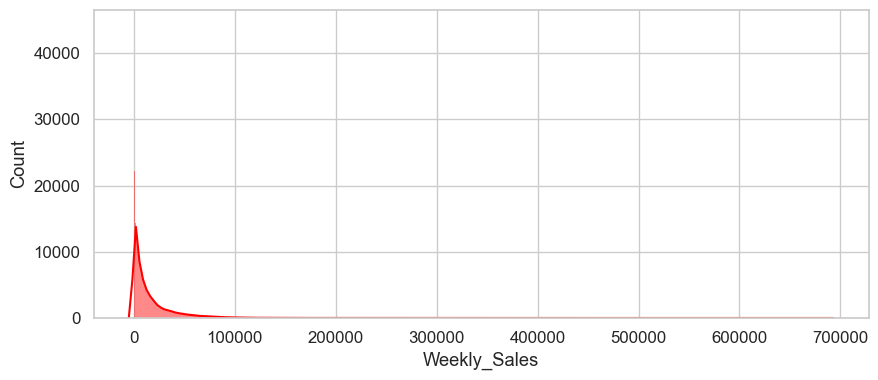

In [ ]:
# 1. Distribution of Weekly Sales

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Weekly_Sales', color='red', kde=True)

plt.show()

**Findings:**

- Weekly sales exhibit a highly right-skewed distribution.
- Most store-department combinations generate relatively low to moderate sales, while a few observations contribute extremely high sales.
- The presence of extreme values suggests demand surges during special events and peak shopping periods.

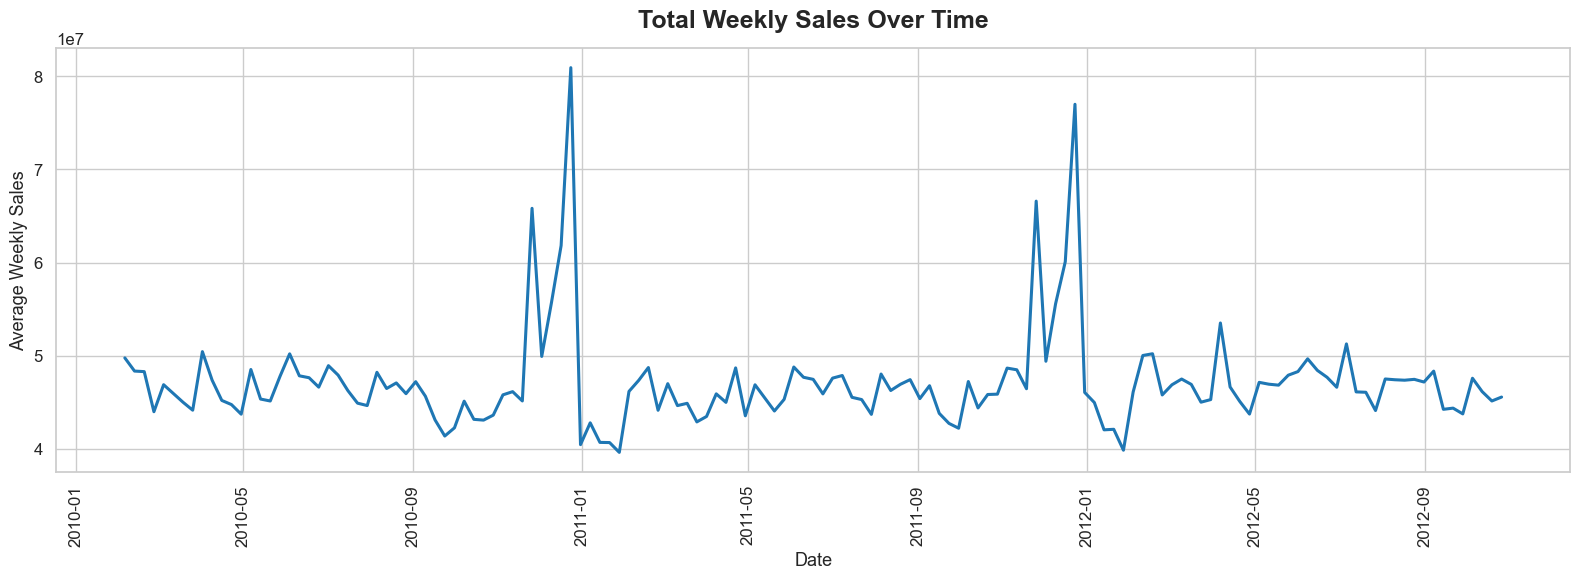

In [ ]:
# 2. How have total weekly sales changed over time?

# Set style
sns.set_theme(style="whitegrid", font_scale=1.1)

# Aggregate weekly sales by date
weekly_sales = df.groupby("Date")["Weekly_Sales"].sum()

# Create figure
plt.figure(figsize=(16, 6))

sns.lineplot(
    x=weekly_sales.index,
    y=weekly_sales.values,
    linewidth=2.2,
    color="#1f77b4"
)
plt.xticks(rotation=90)
plt.title("Total Weekly Sales Over Time", fontsize=18, weight="bold", pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Average Weekly Sales", fontsize=13)
plt.tight_layout()
plt.show()

**Findings:**

- Weekly sales remain relatively stable throughout most of the time period.
- Significant sales spikes are observed during late November and December, indicating holiday shopping seasons such as Thanksgiving and Christmas.
- Sales decline sharply immediately after the holiday period, showing strong seasonality in customer demand.

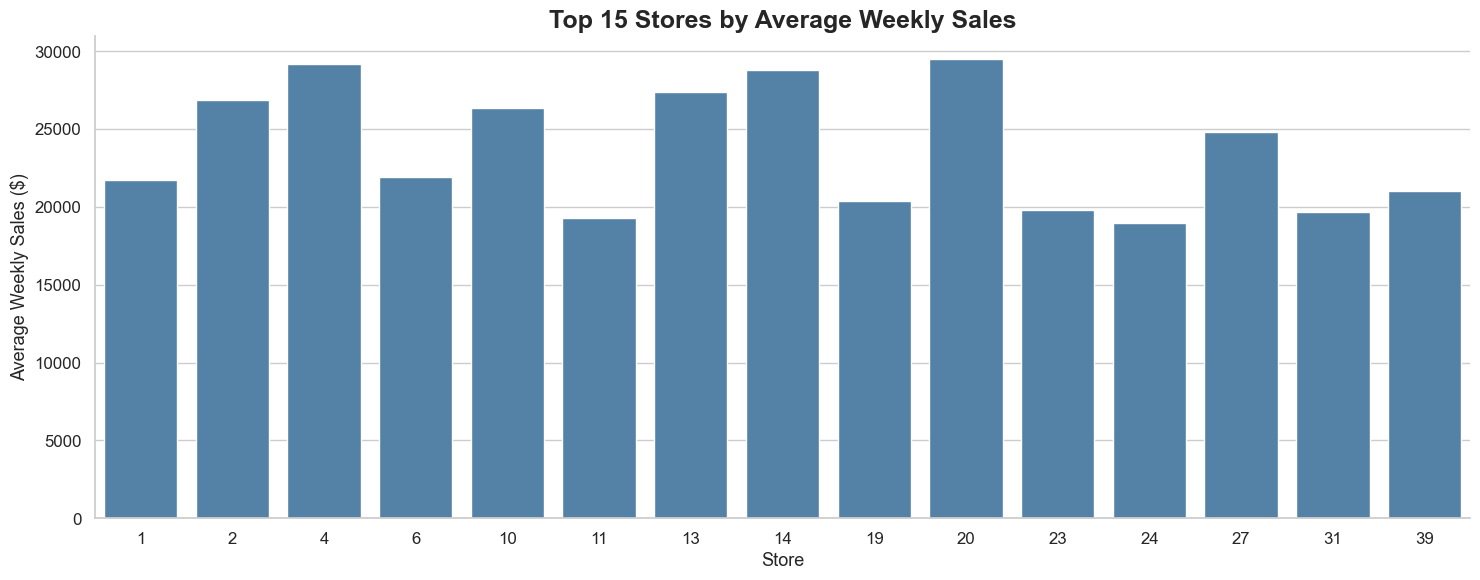

In [ ]:
# 3. Which stores generate the highest sales?

avg_weekly_sales_per_store = (
    df.groupby("Store")["Weekly_Sales"]
      .mean()
      .sort_values(ascending=False)
)

# Extract ONLY the top 15 stores for the visualization
top_15_stores = avg_weekly_sales_per_store.head(15)

# Create the bar plot using the top 15 subset
plt.figure(figsize=(15, 6))

sns.barplot(
    x=top_15_stores.index,      
    y=top_15_stores.values,     
    color="steelblue"
)
plt.title("Top 15 Stores by Average Weekly Sales", fontsize=18, weight="bold")
plt.xlabel("Store", fontsize=13)
plt.ylabel("Average Weekly Sales ($)", fontsize=13)
plt.xticks(rotation=0)          

sns.despine()
plt.tight_layout()
plt.show()

**Findings:**

- A small number of stores consistently achieve higher average weekly sales than others.
- Store 20 records the highest average weekly sales among all stores.
- Sales performance varies considerably across stores, highlighting differences in customer traffic and store size.

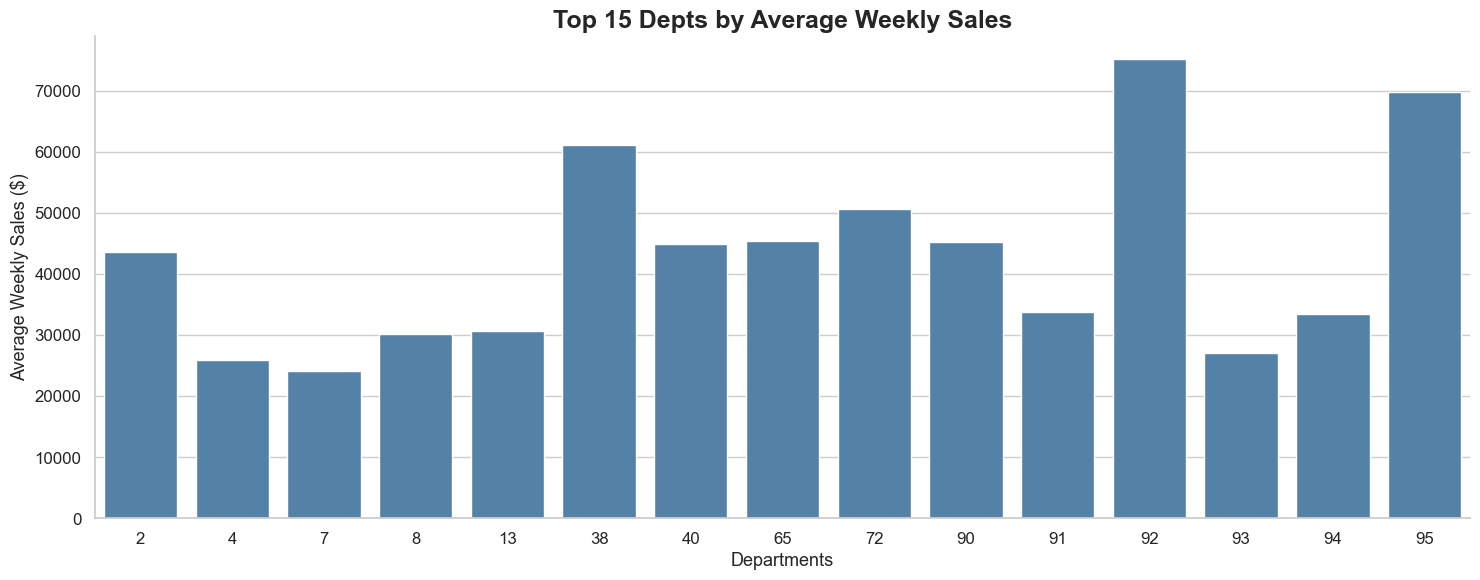

In [ ]:
# 4. Which departments contribute the most sales?

avg_weekly_sales_per_dept = (
    df.groupby("Dept")["Weekly_Sales"]
      .mean()
      .sort_values(ascending=False)
)

# 2. Extract ONLY the top 15 Depts for the visualization
top_15_dept = avg_weekly_sales_per_dept.head(15)

# 3. Create the bar plot using the top 15 subset
plt.figure(figsize=(15, 6))

sns.barplot(
    x=top_15_dept.index,      # Uses only the top 15 Dept IDs
    y=top_15_dept.values,     # Uses only the top 15 sales values
    color="steelblue"
)

# 4. Add styling details
plt.title("Top 15 Depts by Average Weekly Sales", fontsize=18, weight="bold")
plt.xlabel("Departments", fontsize=13)
plt.ylabel("Average Weekly Sales ($)", fontsize=13)
plt.xticks(rotation=0)          # 0 degrees is cleaner since there are only 15 items now

sns.despine()
plt.tight_layout()
plt.show()

**Findings:**

- Certain departments contribute substantially more revenue than others.
- Departments 92 and 95 generate the highest average weekly sales.
- Demand varies significantly across departments, indicating different customer purchasing patterns.

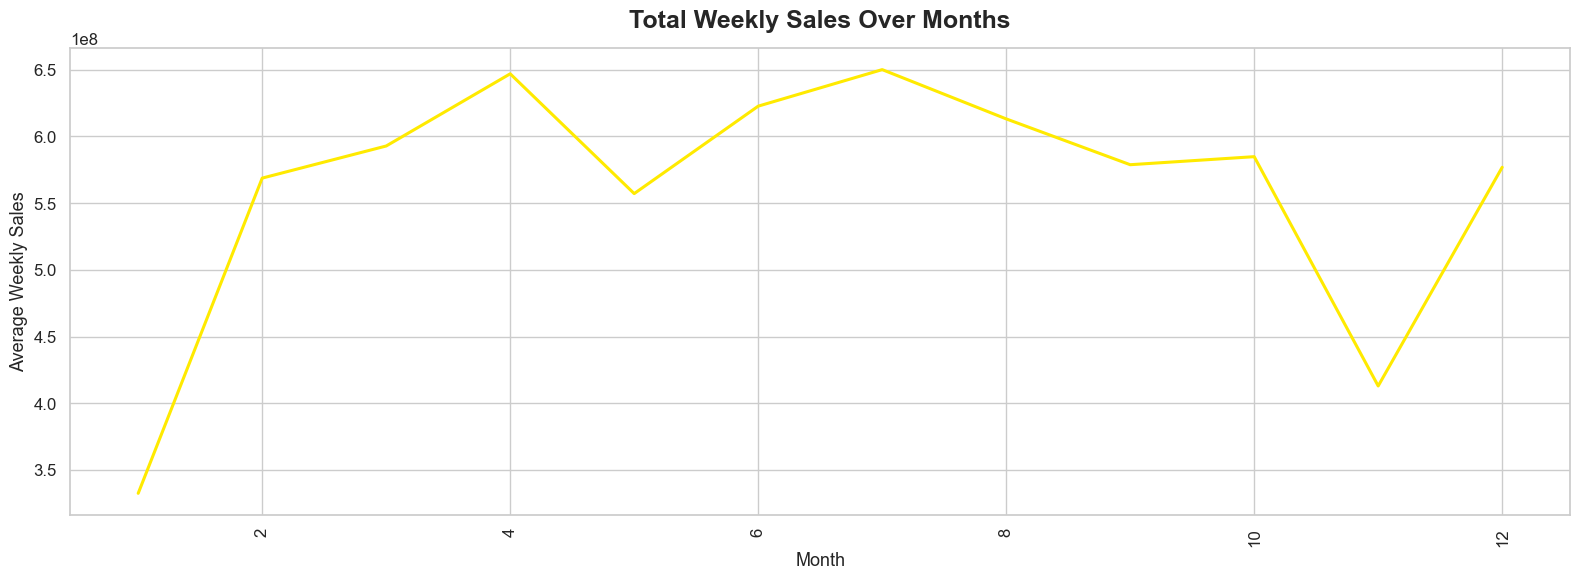

In [ ]:
# 5. Monthly Sales Trend ?

# Set style
sns.set_theme(style="whitegrid", font_scale=1.1)

# Aggregate weekly sales by date
weekly_sales = df.groupby(df["Date"].dt.month)["Weekly_Sales"].sum()

# Create figure
plt.figure(figsize=(16, 6))

sns.lineplot(
    x=weekly_sales.index,
    y=weekly_sales.values,
    linewidth=2.2,
    color="#FFEA00"
)
plt.xticks(rotation=90)
plt.title("Total Weekly Sales Over Months", fontsize=18, weight="bold", pad=15)
plt.xlabel("Month", fontsize=13)
plt.ylabel("Average Weekly Sales", fontsize=13)
plt.tight_layout()
plt.show()

**Findings:**

- Monthly sales follow a clear seasonal trend.
- Sales increase during the middle of the year and reach their highest levels around July.
- A noticeable decline is observed in November, followed by recovery in December.

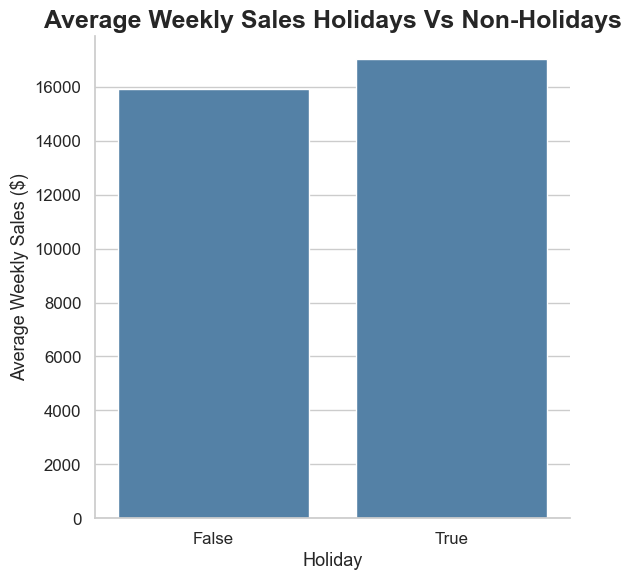

In [ ]:
# 6. Do holidays increase sales?

avg_sales_holiday = df.groupby('IsHoliday')['Weekly_Sales'].mean()

plt.figure(figsize=(6, 6))

sns.barplot(
    x=avg_sales_holiday.index,
    y=avg_sales_holiday.values,
    color="steelblue"
)

# 4. Add styling details
plt.title("Average Weekly Sales Holidays Vs Non-Holidays", fontsize=18, weight="bold")
plt.xlabel("Holiday", fontsize=13)
plt.ylabel("Average Weekly Sales ($)", fontsize=13)
plt.xticks(rotation=0)          # 0 degrees is cleaner since there are only 15 items now

sns.despine()
plt.tight_layout()
plt.show()

**Findings:**

- Average weekly sales are slightly higher during holiday weeks compared to non-holiday weeks.
- Holidays positively influence customer purchasing behavior.
- Holiday periods are an important factor for retail demand forecasting.

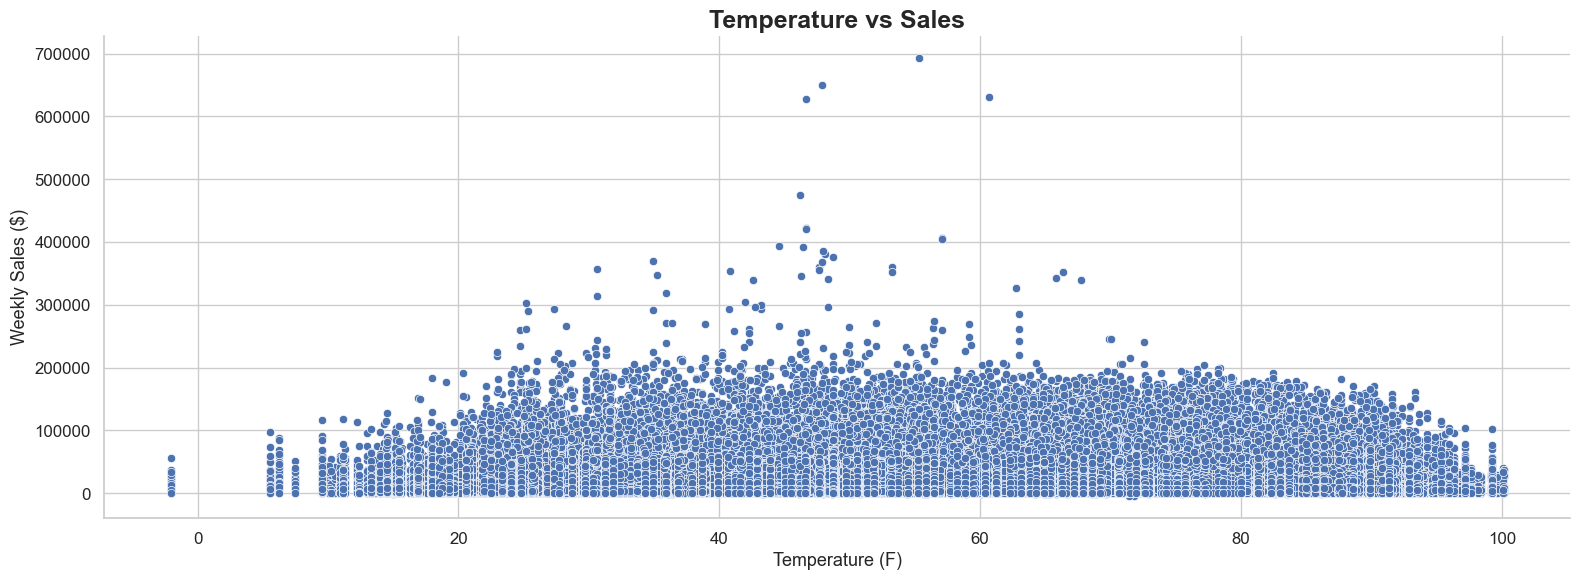

In [ ]:
# 7. Temperature vs Sales

plt.figure(figsize=(16, 6))

sns.scatterplot(x=df['Temperature'], y=df['Weekly_Sales'])

# 4. Add styling details
plt.title("Temperature vs Sales", fontsize=18, weight="bold")
plt.xlabel("Temperature (F)", fontsize=13)
plt.ylabel("Weekly Sales ($)", fontsize=13)
plt.xticks(rotation=0)          # 0 degrees is cleaner since there are only 15 items now

sns.despine()
plt.tight_layout()
plt.show()


**Findings:**

- No strong linear relationship is observed between temperature and weekly sales.
- Sales remain widely distributed across all temperature ranges.
- Temperature alone is not a significant predictor of weekly sales.

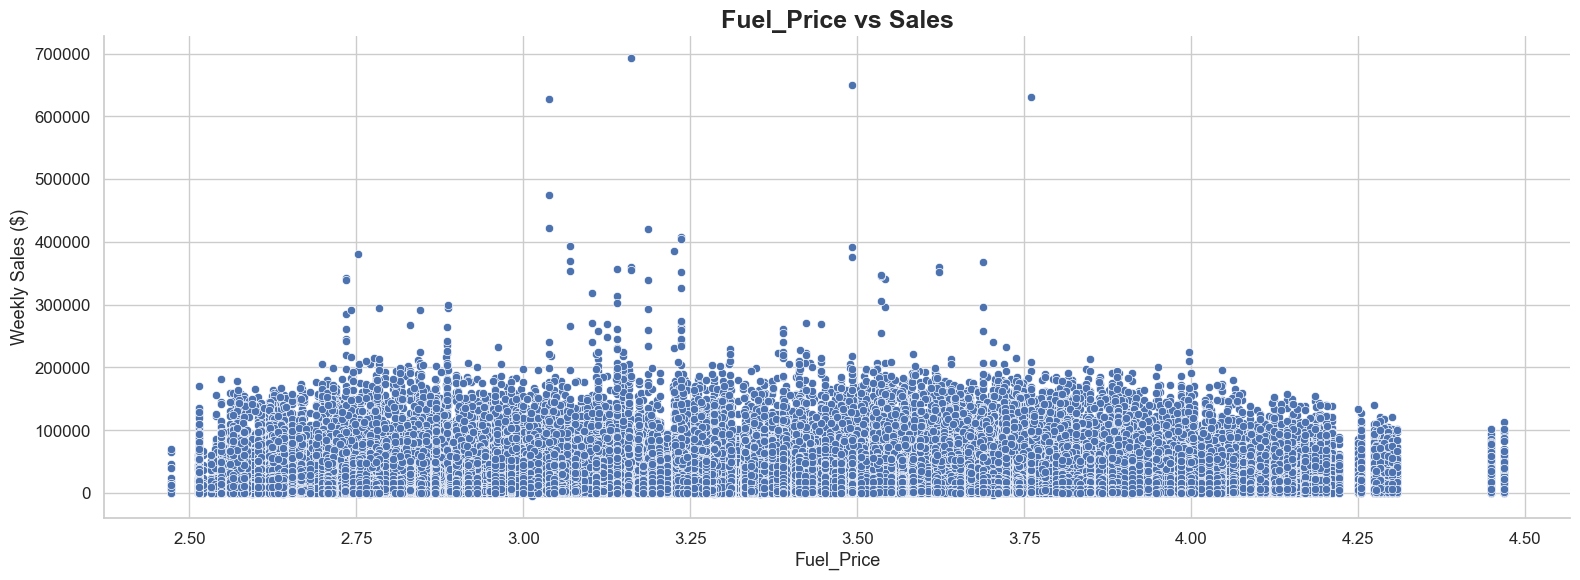

In [ ]:
# 8. Fuel Price vs Sales

plt.figure(figsize=(16, 6))

sns.scatterplot(x=df['Fuel_Price'], y=df['Weekly_Sales'])

# 4. Add styling details
plt.title("Fuel_Price vs Sales", fontsize=18, weight="bold")
plt.xlabel("Fuel_Price", fontsize=13)
plt.ylabel("Weekly Sales ($)", fontsize=13)
plt.xticks(rotation=0)          # 0 degrees is cleaner since there are only 15 items now

sns.despine()
plt.tight_layout()
plt.show()


**Findings:**

- Weekly sales show no clear relationship with fuel prices.
- High and low sales occur across almost all fuel price levels.
- Fuel price appears to have a limited direct impact on retail sales in this dataset.

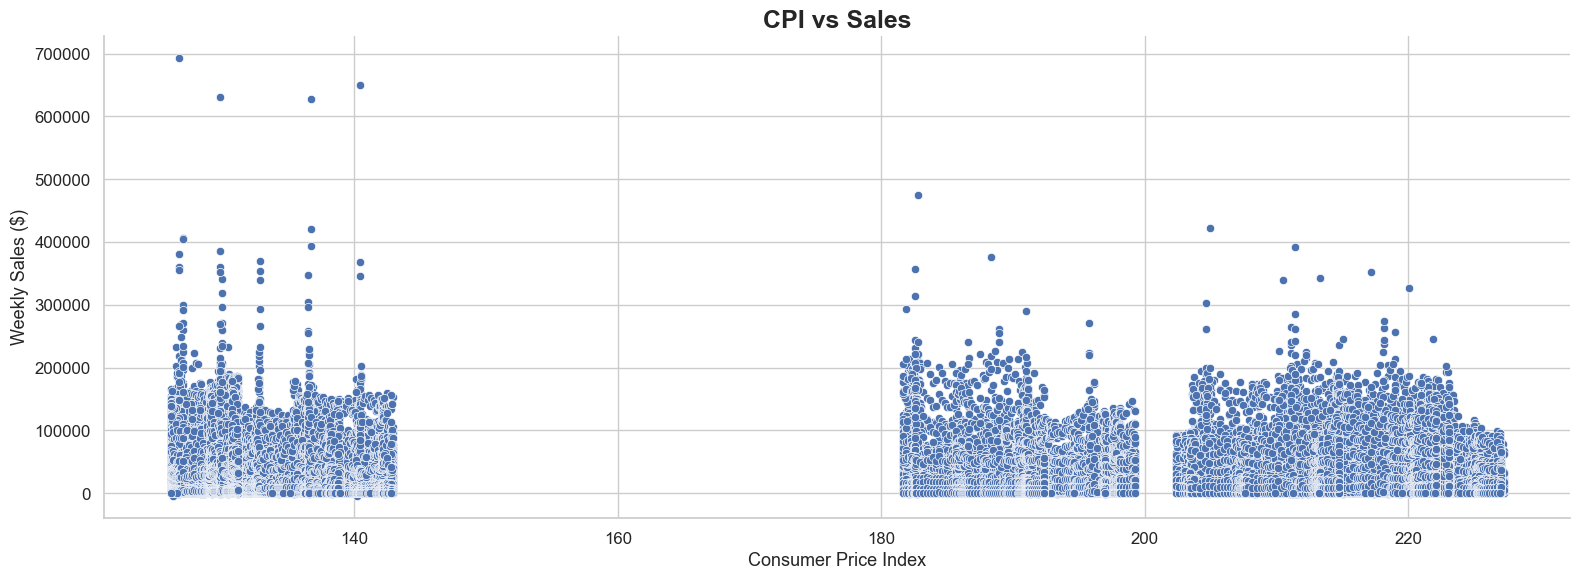

In [117]:
# 9. CPI vs Sales
plt.figure(figsize=(16, 6))

sns.scatterplot(x=df['CPI'], y=df['Weekly_Sales'])

# 4. Add styling details
plt.title("CPI vs Sales", fontsize=18, weight="bold")
plt.xlabel("Consumer Price Index", fontsize=13)
plt.ylabel("Weekly Sales ($)", fontsize=13)
plt.xticks(rotation=0)          # 0 degrees is cleaner since there are only 15 items now

sns.despine()
plt.tight_layout()
plt.show()


**Findings:**

- Weekly sales are distributed across different Consumer Price Index (CPI) values without a clear trend.
- No strong correlation between CPI and sales is visually observed.
- CPI may provide contextual economic information but is unlikely to be a dominant predictor.

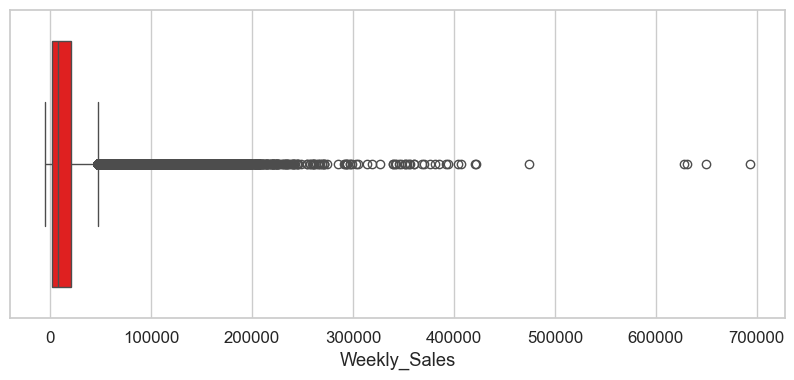

In [119]:
# 8. Outlier Detection
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='Weekly_Sales', color='red')

plt.show()

**Findings:**

- Weekly sales contain a large number of high-value outliers.
- These outliers are likely associated with promotional events and holiday demand spikes.
- The outliers were retained because they represent genuine business events rather than data errors.

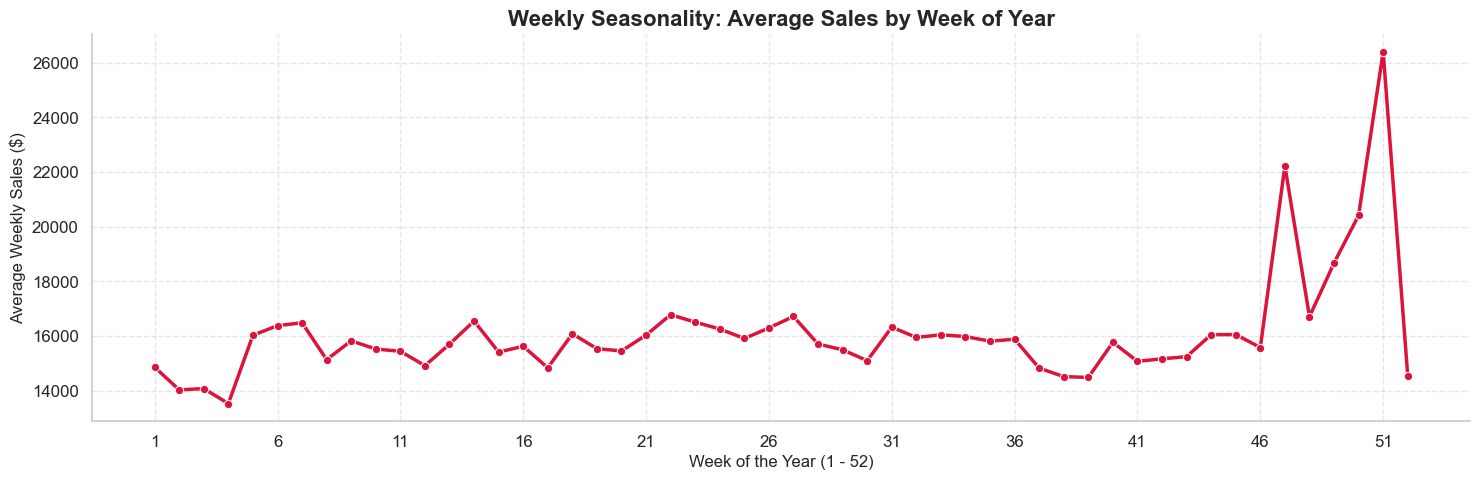

In [ ]:
# 9. Weekly Seasonality

# Extract the Week of the Year (1 to 52) from the Date column
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

# Calculate the Average Sales for each week of the year
weekly_seasonality = df.groupby('WeekOfYear')['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(15, 5))
sns.lineplot(
    data=weekly_seasonality, 
    x='WeekOfYear', 
    y='Weekly_Sales', 
    color='crimson', 
    linewidth=2.5,
    marker='o'
)

plt.title("Weekly Seasonality: Average Sales by Week of Year", fontsize=16, weight="bold")
plt.xlabel("Week of the Year (1 - 52)", fontsize=12)
plt.ylabel("Average Weekly Sales ($)", fontsize=12)

# every 5th week is labeled on the x-axis for easier reading
plt.xticks(range(1, 54, 5))
plt.grid(axis='both', linestyle='--', alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()

**Findings:**

- Weekly sales remain relatively stable throughout most weeks of the year.
- Significant sales peaks occur during Weeks 47–51, corresponding to the holiday shopping season.
- Week 51 records the highest average weekly sales, highlighting strong year-end demand.

In [ ]:
# droping the WeekofYear.
df.drop(columns=['WeekOfYear'],inplace=True)

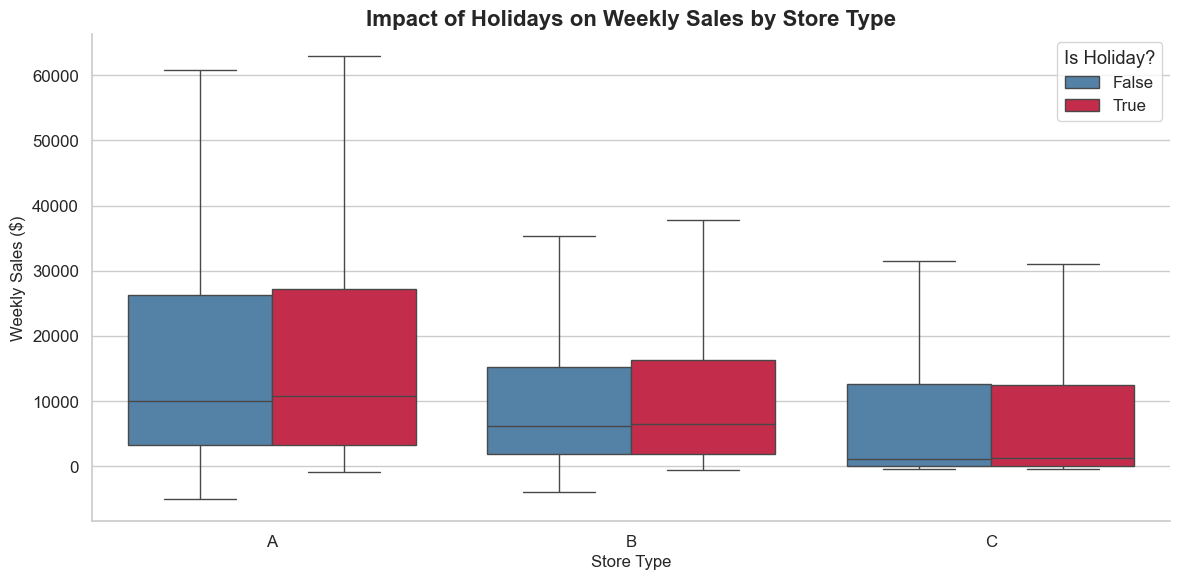

In [ ]:
# 10. Do holiday sales differ across Store Types (A, B, and C)?

plt.figure(figsize=(12, 6))

# 2. Plot the grouped boxplot without extreme outlier points for readability
sns.boxplot(
    data=df,
    x="Type",
    y="Weekly_Sales",
    hue="IsHoliday",
    palette={True: "crimson", False: "steelblue"},  # Clear contrast for holidays
    showfliers=False                                # Hides extreme outliers to keep boxes legible
)
plt.title("Impact of Holidays on Weekly Sales by Store Type", fontsize=16, weight="bold")
plt.xlabel("Store Type", fontsize=12)
plt.ylabel("Weekly Sales ($)", fontsize=12)
plt.legend(title="Is Holiday?", loc="upper right")

sns.despine()
plt.tight_layout()
plt.show()

**Findings:**

- Store Type A consistently generates the highest weekly sales during both holiday and non-holiday periods.
- Holiday weeks show a slight increase in median sales across all store types.
- Larger stores (Type A) appear to benefit the most from holiday shopping demand.


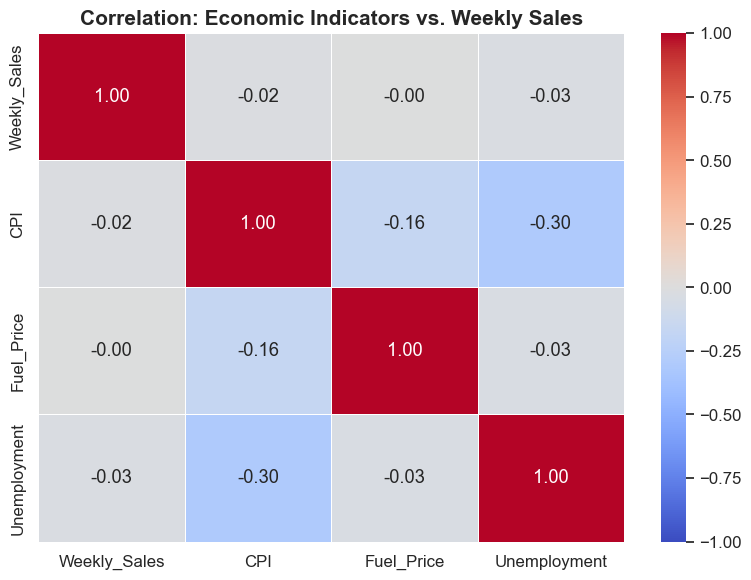

In [ ]:
# 11. How do economic conditions affect weekly sales? (Do CPI, Fuel Price, and Unemployment influence sales?)

economic_cols = ['Weekly_Sales', 'CPI', 'Fuel_Price', 'Unemployment']
macro_df = df[economic_cols]

# Calculate the correlation matrix
correlation_matrix = macro_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix, 
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",        
    vmin=-1,                
    vmax=1,                 
    linewidths=0.5
)
plt.title("Correlation: Economic Indicators vs. Weekly Sales", fontsize=15, weight="bold")
plt.tight_layout()
plt.show()

**Findings:**

- Weekly sales show very weak correlations with CPI, Fuel Price, and Unemployment.
- None of the economic indicators individually exhibit a strong linear relationship with sales.
- This suggests that historical sales patterns and store-specific features are likely stronger predictors of demand.


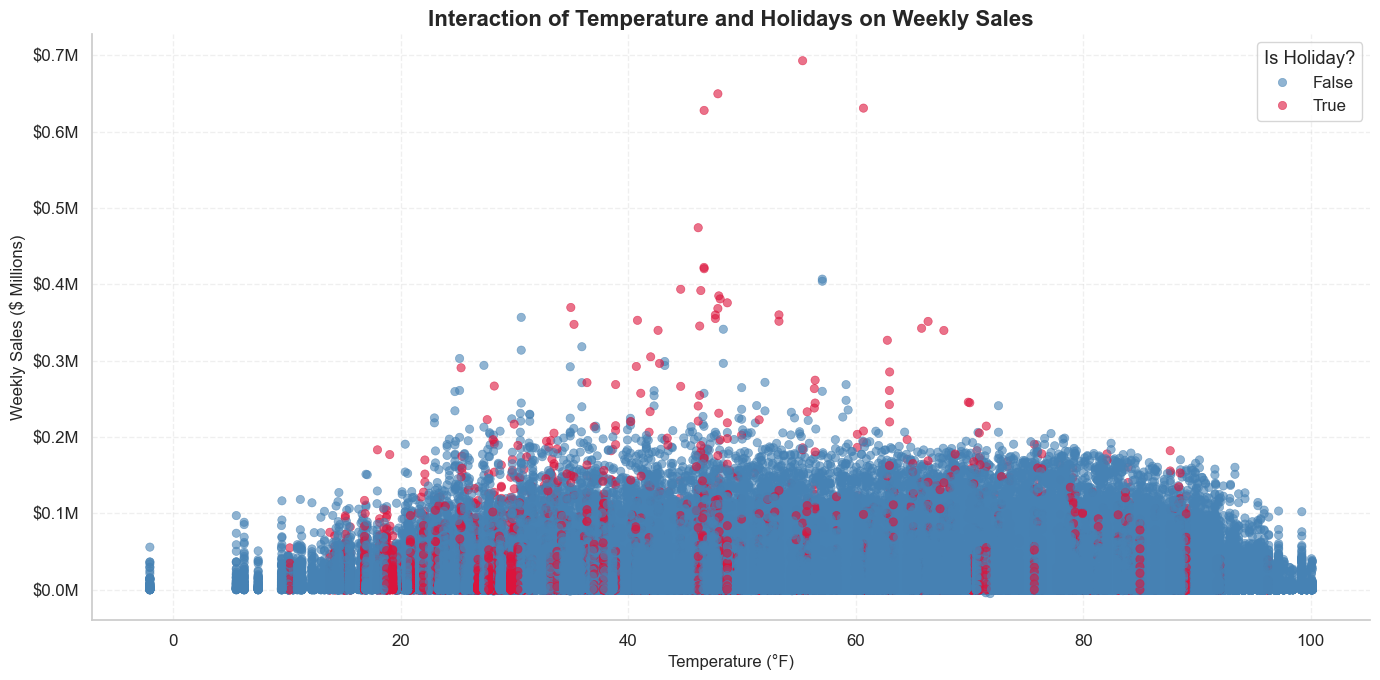

In [ ]:
# 12. How do temperature and holidays together influence sales?

import matplotlib.ticker as ticker

plt.figure(figsize=(14, 7))

# Create the scatter plot with transparency to handle dense data
sns.scatterplot(
    data=df,
    x="Temperature",
    y="Weekly_Sales",
    hue="IsHoliday",
    palette={True: "crimson", False: "steelblue"},  
    alpha=0.6,                                  
    edgecolor=None                                 
)

# converting messy 1e6 notation to Millions
formatter = ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)
plt.title("Interaction of Temperature and Holidays on Weekly Sales", fontsize=16, weight="bold")
plt.xlabel("Temperature (°F)", fontsize=12)
plt.ylabel("Weekly Sales ($ Millions)", fontsize=12)
plt.legend(title="Is Holiday?", loc="upper right")
plt.grid(axis='both', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

**Findings:**

- Holiday observations are associated with several of the highest weekly sales values.
- No clear relationship is observed between temperature and weekly sales.
- Holiday periods have a greater impact on sales than temperature variations.

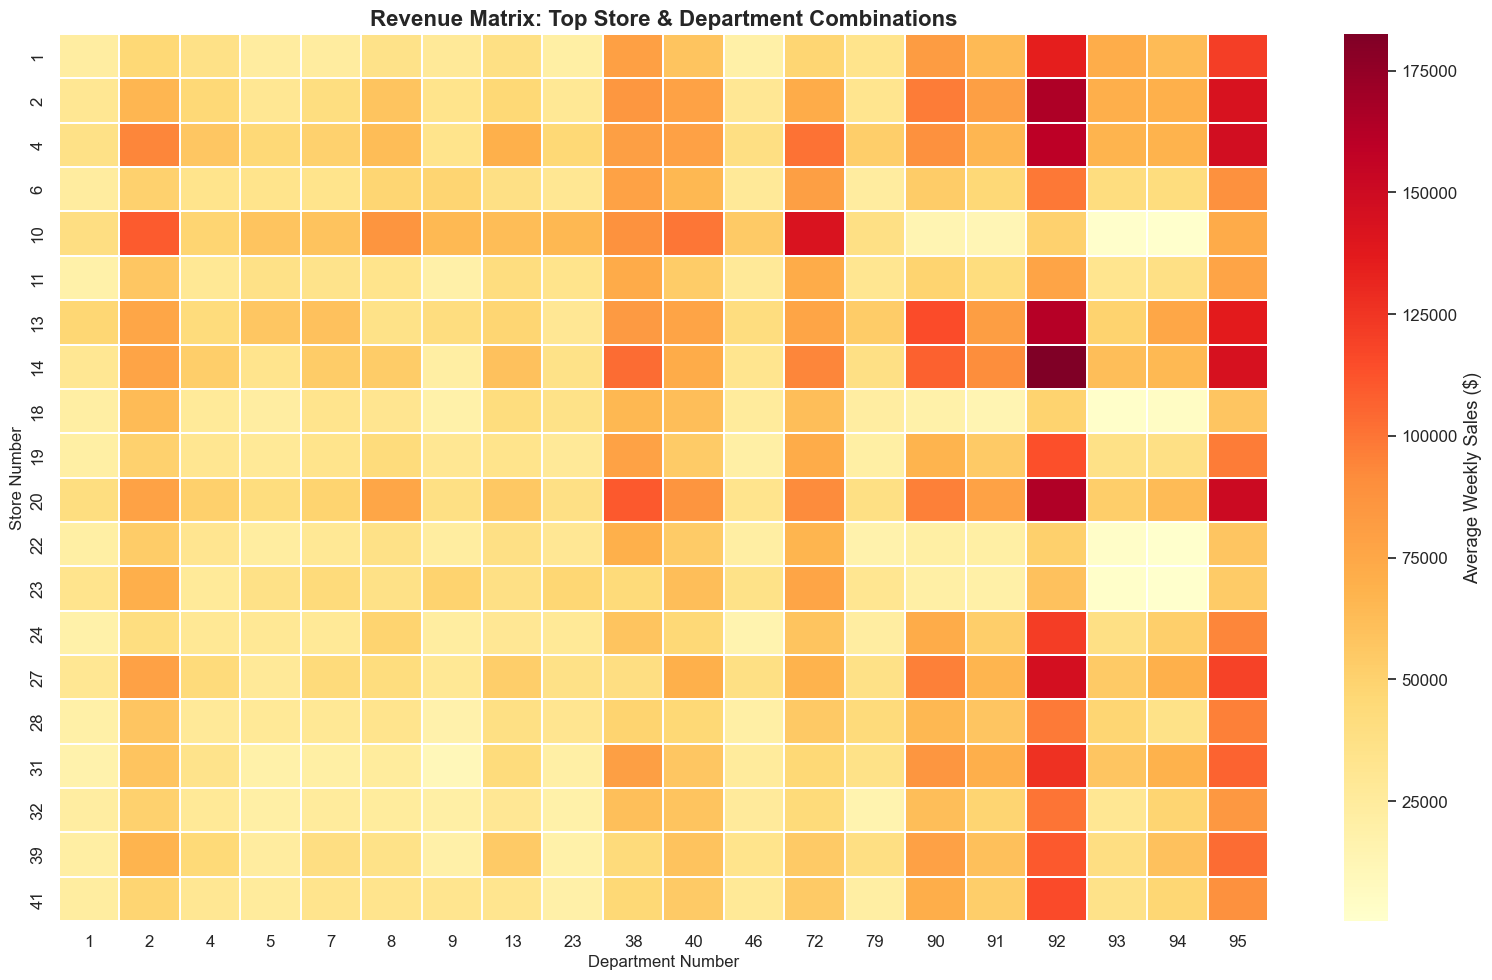

In [ ]:
# 13. Which combinations of Store and Department contribute the most revenue?

top_stores = df.groupby('Store')['Weekly_Sales'].sum().nlargest(20).index
top_depts = df.groupby('Dept')['Weekly_Sales'].sum().nlargest(20).index

# Filtering the main DataFrame to include only these high-volume locations/departments
filtered_df = df[df['Store'].isin(top_stores) & df['Dept'].isin(top_depts)]

# Pivot Table calculating the AVERAGE sales for each combination
sales_pivot = filtered_df.pivot_table(
    values='Weekly_Sales', 
    index='Store', 
    columns='Dept', 
    aggfunc='mean'
)

# Plot the Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    sales_pivot,
    cmap="YlOrRd",          
    annot=False,           
    linewidths=0.1,
    cbar_kws={'label': 'Average Weekly Sales ($)'}
)

plt.title("Revenue Matrix: Top Store & Department Combinations", fontsize=16, weight="bold")
plt.xlabel("Department Number", fontsize=12)
plt.ylabel("Store Number", fontsize=12)

plt.tight_layout()
plt.show()

**Findings:**

- Sales performance varies significantly across different store-department combinations.
- Department 92 consistently generates the highest average weekly sales across multiple stores.
- High-performing departments are concentrated within a subset of stores, indicating opportunities for targeted inventory planning and resource allocation.

## Feature Engineering

In [133]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.57,0.00,0.00,0.00,0.00,0.00,211.10,8.11,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.55,0.00,0.00,0.00,0.00,0.00,211.24,8.11,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.51,0.00,0.00,0.00,0.00,0.00,211.29,8.11,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.56,0.00,0.00,0.00,0.00,0.00,211.32,8.11,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.62,0.00,0.00,0.00,0.00,0.00,211.35,8.11,A,151315


In [134]:
# creating Date features such has Year, Month, WeekofYear, Quarter

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

In [136]:
## Creating Lag Features (A lag feature tells the model what sales were in previous weeks.)
df = df.sort_values(["Store", "Dept", "Date"])

df["Lag_1"] = df.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)

In [141]:
# Creating a Rolling Mean of last 4 weeks (last one month avg sales)
df["Rolling_Mean_4"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(4).mean())
)

In [143]:
# Instead of five separate markdown columns, create a combined promotion measure
df["Total_MarkDown"] = (
    df["MarkDown1"] +
    df["MarkDown2"] +
    df["MarkDown3"] +
    df["MarkDown4"] +
    df["MarkDown5"]
)

In [ ]:
# Checking the Null values cause, by creating Lag_1 and Rolling_mean_4 will create the NaN for Intial rows
df.isnull().sum()

Store                 0
Dept                  0
Date                  0
Weekly_Sales          0
IsHoliday             0
Temperature           0
Fuel_Price            0
MarkDown1             0
MarkDown2             0
MarkDown3             0
MarkDown4             0
MarkDown5             0
CPI                   0
Unemployment          0
Type                  0
Size                  0
Year                  0
Month                 0
WeekOfYear            0
Quarter               0
Lag_1              3331
Rolling_Mean_4    13134
Total_MarkDown        0
dtype: int64

In [ ]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Type,Size,Year,Month,WeekOfYear,Quarter,Lag_1,Rolling_Mean_4,Total_MarkDown
0,1,1,2010-02-05,24924.50,False,42.31,2.57,0.00,0.00,0.00,...,8.11,A,151315,2010,2,5,1,NaN,NaN,0.00
1,1,1,2010-02-12,46039.49,True,38.51,2.55,0.00,0.00,0.00,...,8.11,A,151315,2010,2,6,1,24924.50,NaN,0.00
2,1,1,2010-02-19,41595.55,False,39.93,2.51,0.00,0.00,0.00,...,8.11,A,151315,2010,2,7,1,46039.49,NaN,0.00
3,1,1,2010-02-26,19403.54,False,46.63,2.56,0.00,0.00,0.00,...,8.11,A,151315,2010,2,8,1,41595.55,NaN,0.00
4,1,1,2010-03-05,21827.90,False,46.50,2.62,0.00,0.00,0.00,...,8.11,A,151315,2010,3,9,1,19403.54,32990.77,0.00


In [ ]:
# Droping the initial NaN rows created by lag and rolling window features
df = df.dropna(subset=["Lag_1", "Rolling_Mean_4"])

# Verifing no missing values in data
print("Missing values remaining:")
print(df[["Lag_1", "Rolling_Mean_4"]].isna().sum())

Missing values remaining:
Lag_1             0
Rolling_Mean_4    0
dtype: int64


In [150]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Type,Size,Year,Month,WeekOfYear,Quarter,Lag_1,Rolling_Mean_4,Total_MarkDown
4,1,1,2010-03-05,21827.90,False,46.50,2.62,0.00,0.00,0.00,...,8.11,A,151315,2010,3,9,1,19403.54,32990.77,0.00
5,1,1,2010-03-12,21043.39,False,57.79,2.67,0.00,0.00,0.00,...,8.11,A,151315,2010,3,10,1,21827.90,32216.62,0.00
6,1,1,2010-03-19,22136.64,False,54.58,2.72,0.00,0.00,0.00,...,8.11,A,151315,2010,3,11,1,21043.39,25967.60,0.00
7,1,1,2010-03-26,26229.21,False,51.45,2.73,0.00,0.00,0.00,...,8.11,A,151315,2010,3,12,1,22136.64,21102.87,0.00
8,1,1,2010-04-02,57258.43,False,62.27,2.72,0.00,0.00,0.00,...,7.81,A,151315,2010,4,13,2,26229.21,22809.28,0.00


In [151]:
df['Date'].max()

Timestamp('2012-10-26 00:00:00')

In [170]:
# splitting the data last 26 weeks for Validation and Remainig for Trainig

# all unique weekly dates
unique_dates = sorted(df["Date"].unique())

# Reserve the last 26 weeks for validation
cutoff_date = unique_dates[-26]

# Time-based split
final_train_df = df[df["Date"] < cutoff_date].copy()
final_val_df = df[df["Date"] >= cutoff_date].copy()

# Verification
print(f"Cutoff Date: {cutoff_date.date()}")
print(f"Training Date Range: {final_train_df['Date'].min().date()} → {final_train_df['Date'].max().date()}")
print(f"Validation Date Range: {final_val_df['Date'].min().date()} → {final_val_df['Date'].max().date()}")
print(f"Validation Weeks: {final_val_df['Date'].nunique()}")


Cutoff Date: 2012-05-04
Training Date Range: 2010-03-05 → 2012-04-27
Validation Date Range: 2012-05-04 → 2012-10-26
Validation Weeks: 26


In [172]:
# Create the folder and Saving the Final Train and Val for ML modeling

output_path = Path("data/modeling")
output_path.mkdir(parents=True, exist_ok=True)

# Save train and validation datasets
final_train_df.to_csv(output_path / "train_ml.csv", index=False)
final_val_df.to_csv(output_path / "validation_ml.csv", index=False)

print("ML datasets saved successfully!")
print(f"Train      : {output_path / 'train_final.csv'}")
print(f"Validation : {output_path / 'validation_final.csv'}")

ML datasets saved successfully!
Train      : data\modeling\train_final.csv
Validation : data\modeling\validation_final.csv
